In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Imbalanced Data Handling
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

In [37]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [38]:
print("\nFIRST 5 ROWS OF DATASET")
print(df.head())


FIRST 5 ROWS OF DATASET
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [39]:
print("\nINFORMATION ABOUT DATASET")
df.info()
print("Data_Description")
df.describe()


INFORMATION ABOUT DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Data_Description


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [40]:
print("\nDATASET SHAPE")
print(df.shape)


DATASET SHAPE
(891, 12)


In [41]:
print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [42]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df['Age'] = df['Age'].fillna(df['Age'].mean())

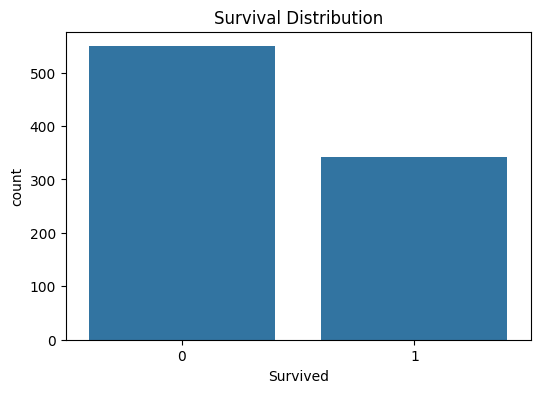

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survived',
    data=df
)

plt.title("Survival Distribution")
plt.show()

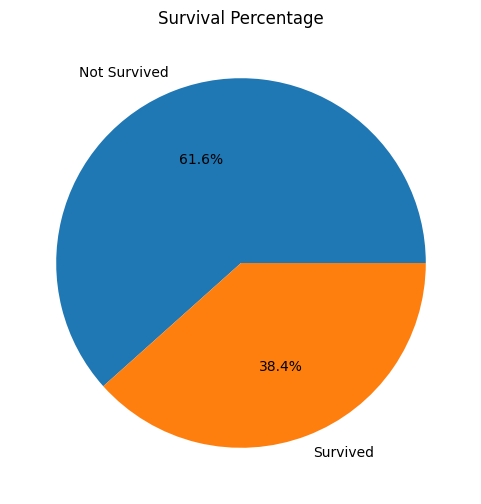

In [44]:
survival_counts = df['Survived'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    survival_counts,
    labels=['Not Survived','Survived'],
    autopct='%1.1f%%'
)

plt.title("Survival Percentage")
plt.show()

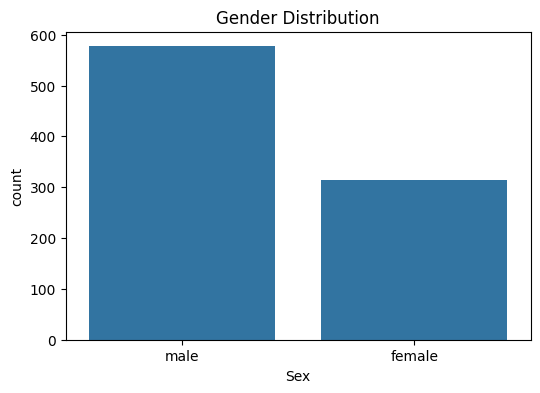

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    data=df
)

plt.title("Gender Distribution")
plt.show()

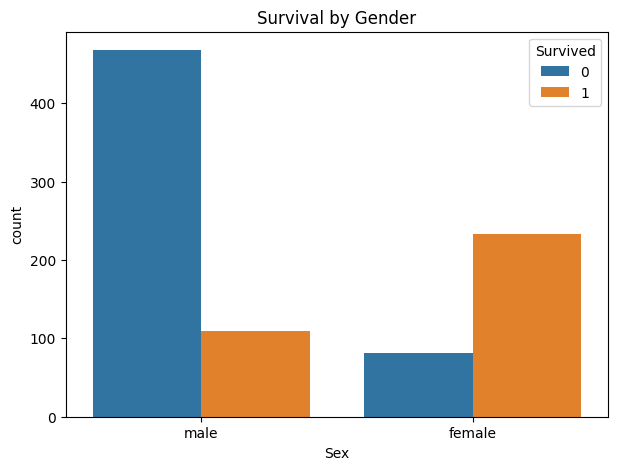

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")
plt.show()

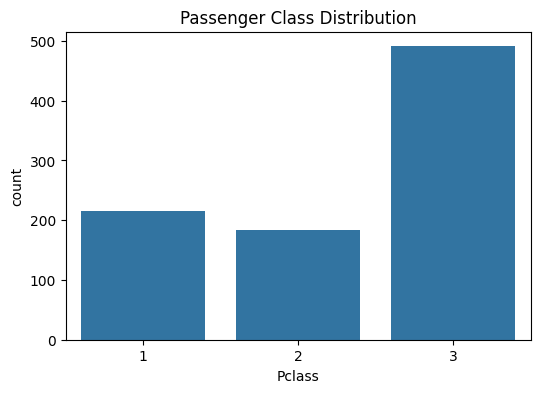

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Pclass',
    data=df
)

plt.title("Passenger Class Distribution")
plt.show()

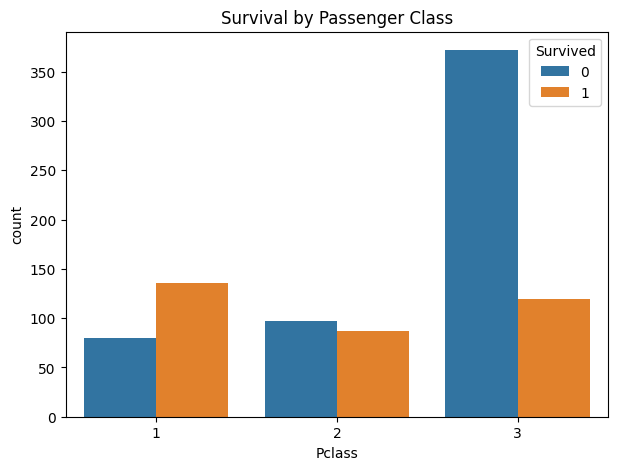

In [48]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Survival by Passenger Class")
plt.show()

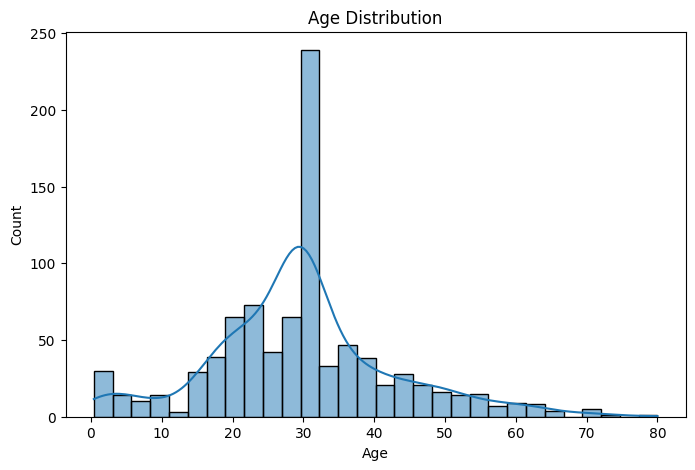

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

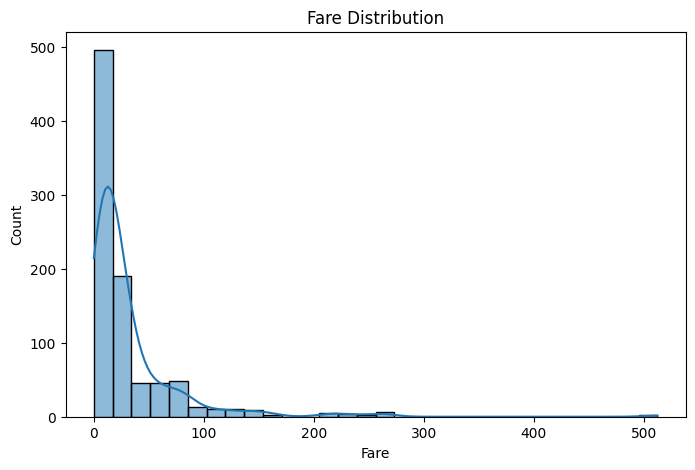

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Fare'],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.show()

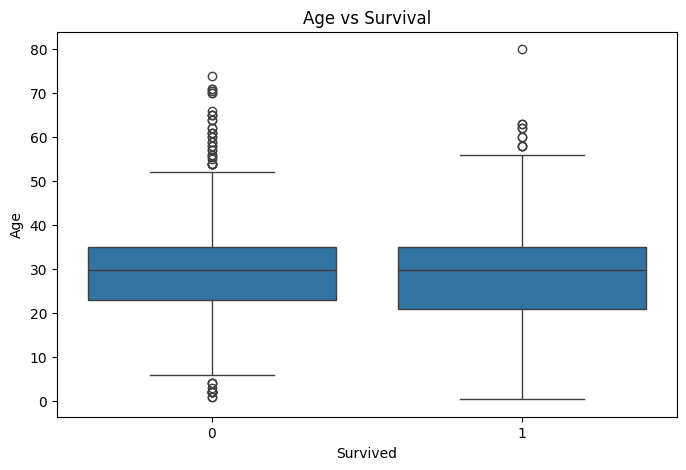

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Survived',
    y='Age',
    data=df
)

plt.title("Age vs Survival")
plt.show()

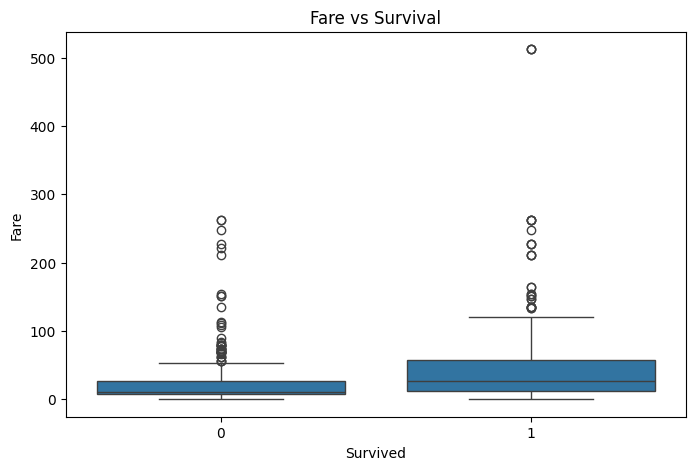

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Survived',
    y='Fare',
    data=df
)

plt.title("Fare vs Survival")
plt.show()

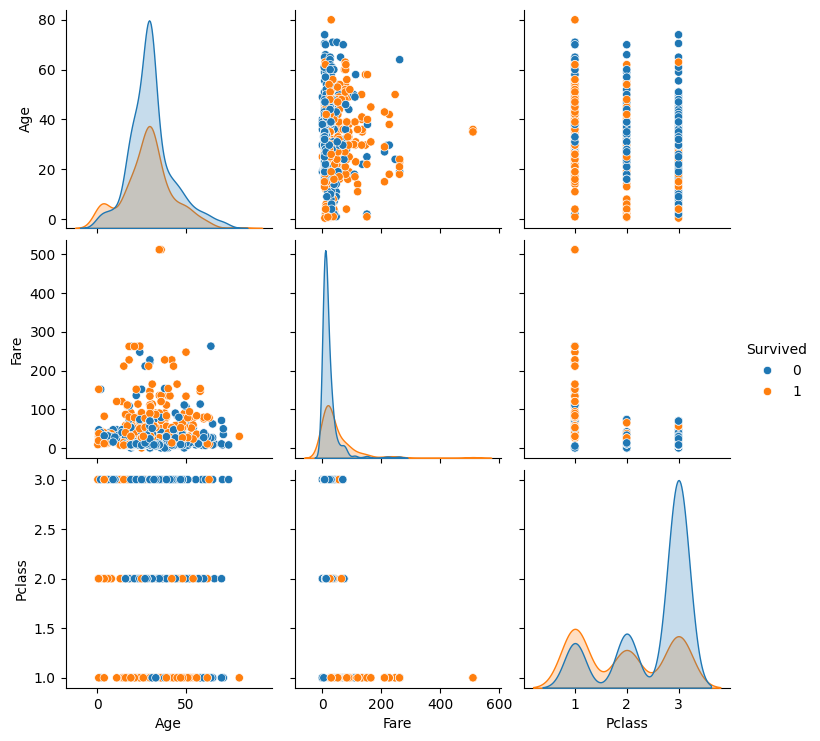

In [53]:
sns.pairplot(
    df,
    hue='Survived',
    vars=['Age','Fare','Pclass']
)

plt.show()

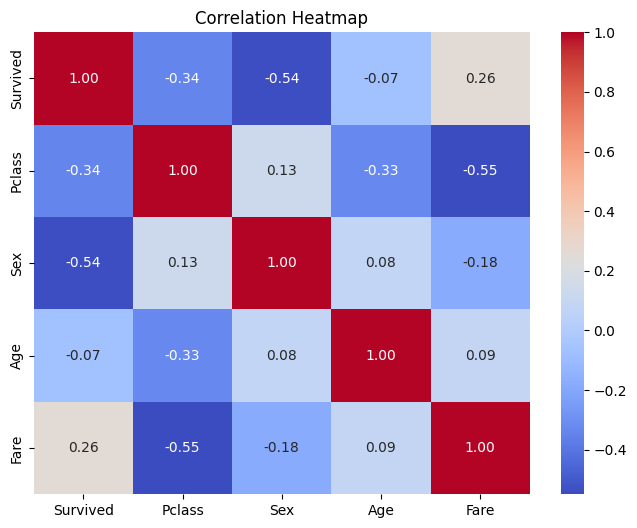

In [54]:
temp_df = df.copy()

le = LabelEncoder()
temp_df['Sex'] = le.fit_transform(temp_df['Sex'])

plt.figure(figsize=(8,6))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [55]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])


In [56]:
X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

scaler = StandardScaler()
X = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("\nAFTER SMOTE")
print(pd.Series(y).value_counts())


AFTER SMOTE
Survived
0    549
1    549
Name: count, dtype: int64


In [57]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [58]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

In [59]:

accuracy_list = []
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    accuracy_list.append(acc)
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Confusion Matrix": cm.tolist()
    }

print("\nTRAINING AND EVALUATION RESULTS:")
for name, metrics in results.items():
    print(f"\n--- {name} ---")
    for metric_name, value in metrics.items():
        if metric_name == "Confusion Matrix":
            print(f"{metric_name}:\n{np.array(value)}")
        else:
            print(f"{metric_name}: {value:.4f}")

print("\nAccuracy List:", accuracy_list)



TRAINING AND EVALUATION RESULTS:

--- Logistic Regression ---
Accuracy: 0.8045
Precision: 0.7937
Recall: 0.8547
F1 Score: 0.8230
Confusion Matrix:
[[ 77  26]
 [ 17 100]]

--- KNN ---
Accuracy: 0.8727
Precision: 0.8504
Recall: 0.9231
F1 Score: 0.8852
Confusion Matrix:
[[ 84  19]
 [  9 108]]

--- Decision Tree ---
Accuracy: 0.8182
Precision: 0.8348
Recall: 0.8205
F1 Score: 0.8276
Confusion Matrix:
[[84 19]
 [21 96]]

--- Random Forest ---
Accuracy: 0.8364
Precision: 0.8347
Recall: 0.8632
F1 Score: 0.8487
Confusion Matrix:
[[ 83  20]
 [ 16 101]]

--- SVM ---
Accuracy: 0.8182
Precision: 0.8031
Recall: 0.8718
F1 Score: 0.8361
Confusion Matrix:
[[ 78  25]
 [ 15 102]]

Accuracy List: [0.8045454545454546, 0.8727272727272727, 0.8181818181818182, 0.8363636363636363, 0.8181818181818182]


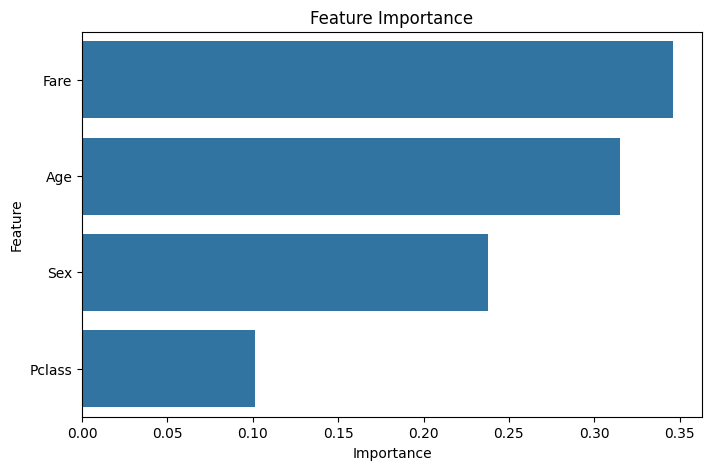

In [61]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

importance = rf.feature_importances_

features = ['Pclass','Sex','Age','Fare']

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")
plt.show()

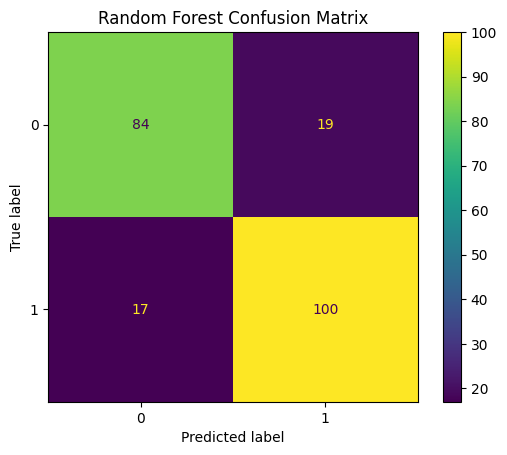

In [62]:
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()